EXERCISE 1


In [ ]:
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)
print(data[data.duplicated()])
print(data)

Empty DataFrame
Columns: [Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []
             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily Ma

In [ ]:
clean_data = data.drop_duplicates(subset=['Name'])
print(clean_data)

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   
...       

EXERCISE 2

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)
print(data)




             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   
...       

In [ ]:
manquants = data.isnull().sum()
print(manquants[manquants > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [ ]:
#delete line that are contained NaN value
delete_data = data.dropna()
print(delete_data)

             Survived  Pclass  \
PassengerId                     
2                   1       1   
4                   1       1   
7                   0       1   
11                  1       3   
12                  1       1   
...               ...     ...   
872                 1       1   
873                 0       1   
880                 1       1   
888                 1       1   
890                 1       1   

                                                          Name     Sex   Age  \
PassengerId                                                                    
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
7                                      McCarthy, Mr. Timothy J    male  54.0   
11                             Sandstrom, Miss. Marguerite Rut  female   4.0   
12                                    Bonnell, Miss. Elizabeth  female  58.0   
...       

In [ ]:
manual_change_data = data.fillna('Unknown')
print(manual_change_data)

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex  \
PassengerId                                                              
1                                      Braund, Mr. Owen Harris    male   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female   
3                                       Heikkinen, Miss. Laina  female   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   
5                                     Allen, Mr. William Henry    male   
...                                                 

In [ ]:
from pandas.core.arrays import numeric
from sklearn.impute import SimpleImputer
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)

imputed = SimpleImputer(strategy='mean')

numeric_data = data.select_dtypes(include=['number']).columns
for col in numeric_data:
    imputed.fit(data[[col]])
    data[col] = imputed.transform(data[[col]])

print(data)

             Survived  Pclass  \
PassengerId                     
1                 0.0     3.0   
2                 1.0     1.0   
3                 1.0     3.0   
4                 1.0     1.0   
5                 0.0     3.0   
...               ...     ...   
887               0.0     2.0   
888               1.0     1.0   
889               0.0     3.0   
890               1.0     1.0   
891               0.0     3.0   

                                                          Name     Sex  \
PassengerId                                                              
1                                      Braund, Mr. Owen Harris    male   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female   
3                                       Heikkinen, Miss. Laina  female   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   
5                                     Allen, Mr. William Henry    male   
...                                                 

EXERCISE 3

In [ ]:
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
#create new feature
data["FamilySize"]= data["SibSp"] + data["Parch"]+1
#extract
data['Title'] = data['Name'].str.extract("([A-Za-z]+)\.",expand= False )
data

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1278/3925679598.py:4: SyntaxWarning: invalid escape sequence '\.'
  data['Title'] = data['Name'].str.extract("([A-Za-z]+)\.",expand= False )


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,Rev
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,Miss


In [ ]:
print(list(set(data['Title'])))
#simplify
data['Title'].replace(['Capt','Major','Don','Countess','Dr','Sir','Rev','Jonkheer','Col','Lady','Master'], 'Rare', inplace=True)
data['Title'].replace(['Ms','Mlle'],'Miss',inplace=True)
data['Title'].replace(['Mme'],'Mrs',inplace= True)
print(list(set(data['Title'])))
data


['Rare', 'Mr', 'Mrs', 'Miss']
['Rare', 'Mr', 'Mrs', 'Miss']


/tmp/ipykernel_1278/3212288796.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Title'].replace(['Capt','Major','Don','Countess','Dr','Sir','Rev','Jonkheer','Col','Lady','Master'], 'Rare', inplace=True)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,Rare
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,Miss


In [ ]:
from numpy import mean
from sklearn.impute import SimpleImputer


Number = SimpleImputer(strategy ='median')
Object = SimpleImputer(strategy = 'most_frequent')
#imputation
Unknown_number = data.select_dtypes(include = ['number']).columns
unknown_object = data.select_dtypes(include = ['object']).columns

data["Name"].drop_duplicates()
for col in Unknown_number:
    print(data[col])
    data[col] = Number.fit_transform(data[[col]])
    print(data[col])

for col in unknown_object:
    print(data[col])
    data[col] = Object.fit_transform(data[[col]]).ravel()
    print(data[col])

data

PassengerId
1      0
2      1
3      1
4      1
5      0
      ..
887    0
888    1
889    0
890    1
891    0
Name: Survived, Length: 891, dtype: int64
PassengerId
1      0.0
2      1.0
3      1.0
4      1.0
5      0.0
      ... 
887    0.0
888    1.0
889    0.0
890    1.0
891    0.0
Name: Survived, Length: 891, dtype: float64
PassengerId
1      3
2      1
3      3
4      1
5      3
      ..
887    2
888    1
889    3
890    1
891    3
Name: Pclass, Length: 891, dtype: int64
PassengerId
1      3.0
2      1.0
3      3.0
4      1.0
5      3.0
      ... 
887    2.0
888    1.0
889    3.0
890    1.0
891    3.0
Name: Pclass, Length: 891, dtype: float64
PassengerId
1      22.0
2      38.0
3      26.0
4      35.0
5      35.0
       ... 
887    27.0
888    19.0
889     NaN
890    26.0
891    32.0
Name: Age, Length: 891, dtype: float64
PassengerId
1      22.0
2      38.0
3      26.0
4      35.0
5      35.0
       ... 
887    27.0
888    19.0
889    28.0
890    26.0
891    32.0
Name: Age, Length

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title
PassengerId,,,,,,,,,,,,,
1,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,B96 B98,S,2.0,Mr
2,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C,2.0,Mrs
3,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,B96 B98,S,1.0,Miss
4,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,2.0,Mrs
5,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,B96 B98,S,1.0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0.0,2.0,"Montvila, Rev. Juozas",male,27.0,0.0,0.0,211536,13.0000,B96 B98,S,1.0,Rare
888,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.0000,B42,S,1.0,Miss
889,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1.0,2.0,W./C. 6607,23.4500,B96 B98,S,4.0,Miss


In [ ]:
import pandas as pd
#encode
data['Sex']= data['Sex'].map({'male':0,'female':1})
data = pd.get_dummies(data ,columns=['Title','Embarked'],drop_first=True)
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,,,,
1,0.0,3.0,"Braund, Mr. Owen Harris",0,22.0,1.0,0.0,A/5 21171,7.2500,B96 B98,2.0,True,False,False,False,True
2,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1.0,0.0,PC 17599,71.2833,C85,2.0,False,True,False,False,False
3,1.0,3.0,"Heikkinen, Miss. Laina",1,26.0,0.0,0.0,STON/O2. 3101282,7.9250,B96 B98,1.0,False,False,False,False,True
4,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1.0,0.0,113803,53.1000,C123,2.0,False,True,False,False,True
5,0.0,3.0,"Allen, Mr. William Henry",0,35.0,0.0,0.0,373450,8.0500,B96 B98,1.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0.0,2.0,"Montvila, Rev. Juozas",0,27.0,0.0,0.0,211536,13.0000,B96 B98,1.0,False,False,True,False,True
888,1.0,1.0,"Graham, Miss. Margaret Edith",1,19.0,0.0,0.0,112053,30.0000,B42,1.0,False,False,False,False,True
889,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1.0,2.0,W./C. 6607,23.4500,B96 B98,4.0,False,False,False,False,True


In [ ]:
#keep essential data
data.drop(['Name', 'Ticket', 'Cabin'],errors = 'ignore', axis=1, inplace=True)
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
1,0.0,3.0,0,22.0,1.0,0.0,7.2500,2.0,True,False,False,False,True
2,1.0,1.0,1,38.0,1.0,0.0,71.2833,2.0,False,True,False,False,False
3,1.0,3.0,1,26.0,0.0,0.0,7.9250,1.0,False,False,False,False,True
4,1.0,1.0,1,35.0,1.0,0.0,53.1000,2.0,False,True,False,False,True
5,0.0,3.0,0,35.0,0.0,0.0,8.0500,1.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0.0,2.0,0,27.0,0.0,0.0,13.0000,1.0,False,False,True,False,True
888,1.0,1.0,1,19.0,0.0,0.0,30.0000,1.0,False,False,False,False,True
889,0.0,3.0,1,28.0,1.0,2.0,23.4500,4.0,False,False,False,False,True


EXERCSE 4


['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']


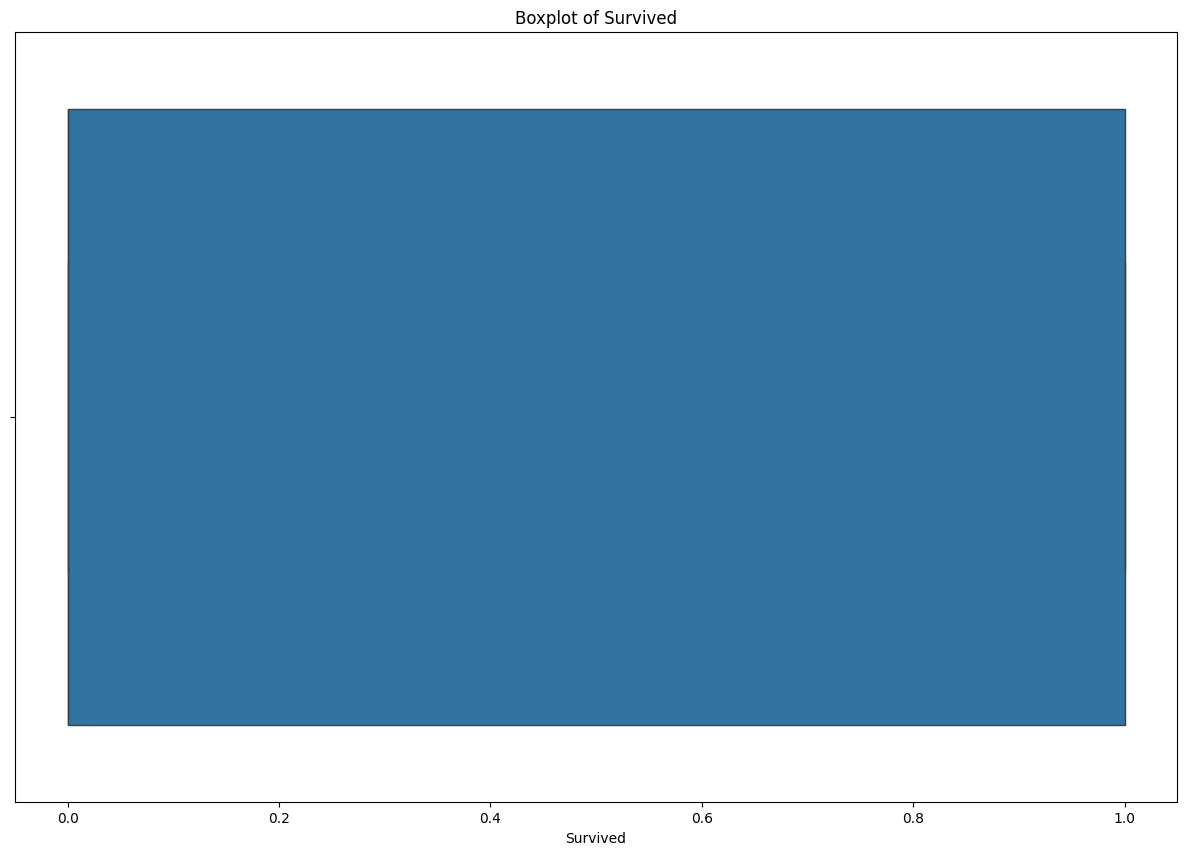

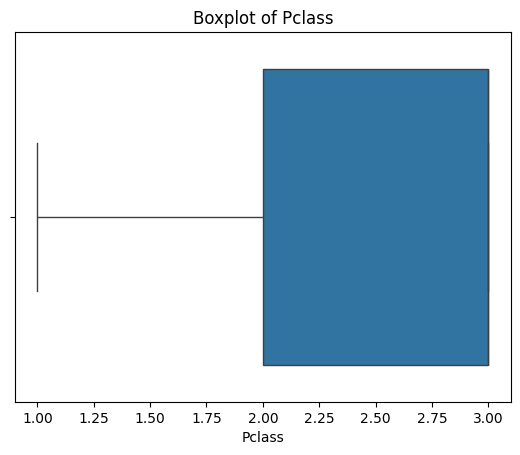

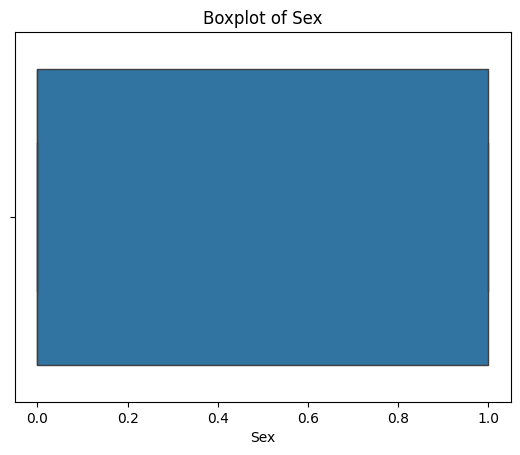

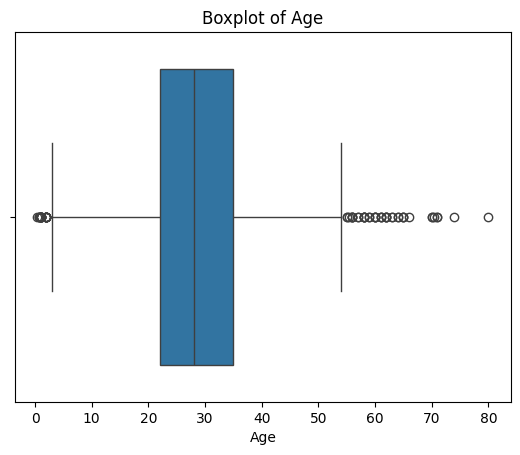

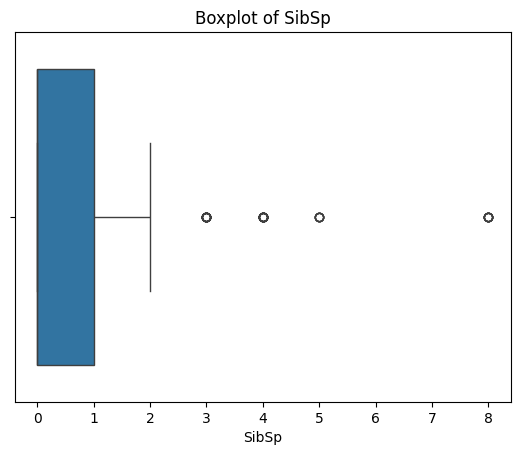

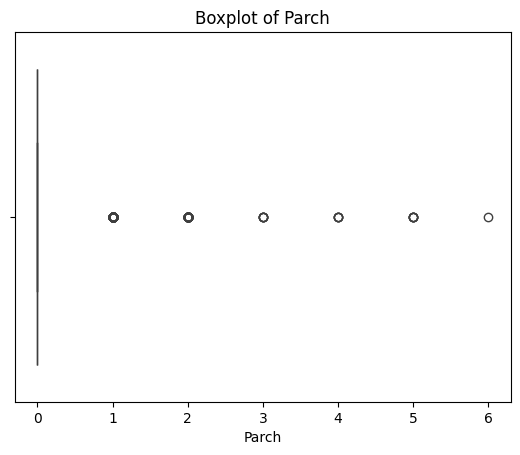

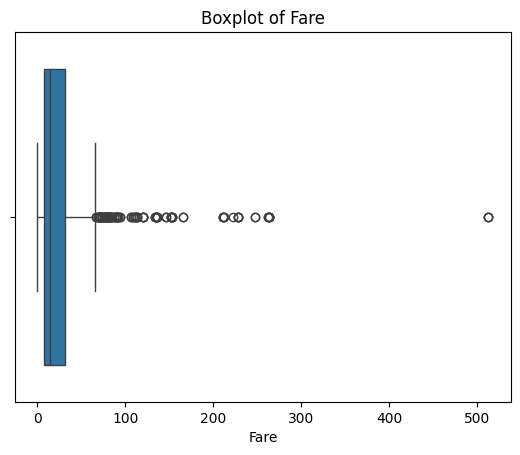

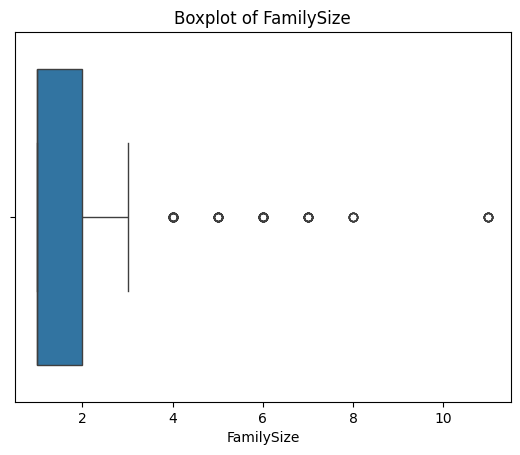

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
print(numeric_cols)

plt.figure(figsize=(15, 10))
for col in numeric_cols:
    sns.boxplot(data=data, x=f'{col}')
    plt.title(f"Boxplot of {col}")
    plt.show()





In [21]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # On retourne le DataFrame filtré
    return df[(df[column] > lower) & (df[column] < upper)]


In [23]:
# Maintenant, on boucle sur tes colonnes numériques pour nettoyer le df original
data_copy = data.copy()
for col in data_copy.select_dtypes(include="number").columns.tolist():
    if data[col].nunique() > 2:
        data_copy = remove_outliers_iqr(data, col)

print("DataFrame nettoyé, nouvelle forme :")
data_copy

DataFrame nettoyé, nouvelle forme :


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
1,0.0,3.0,0,22.0,1.0,0.0,7.2500,2.0,True,False,False,False,True
2,1.0,1.0,1,38.0,1.0,0.0,71.2833,2.0,False,True,False,False,False
3,1.0,3.0,1,26.0,0.0,0.0,7.9250,1.0,False,False,False,False,True
4,1.0,1.0,1,35.0,1.0,0.0,53.1000,2.0,False,True,False,False,True
5,0.0,3.0,0,35.0,0.0,0.0,8.0500,1.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0.0,3.0,0,25.0,0.0,0.0,7.0500,1.0,True,False,False,False,True
887,0.0,2.0,0,27.0,0.0,0.0,13.0000,1.0,False,False,True,False,True
888,1.0,1.0,1,19.0,0.0,0.0,30.0000,1.0,False,False,False,False,True


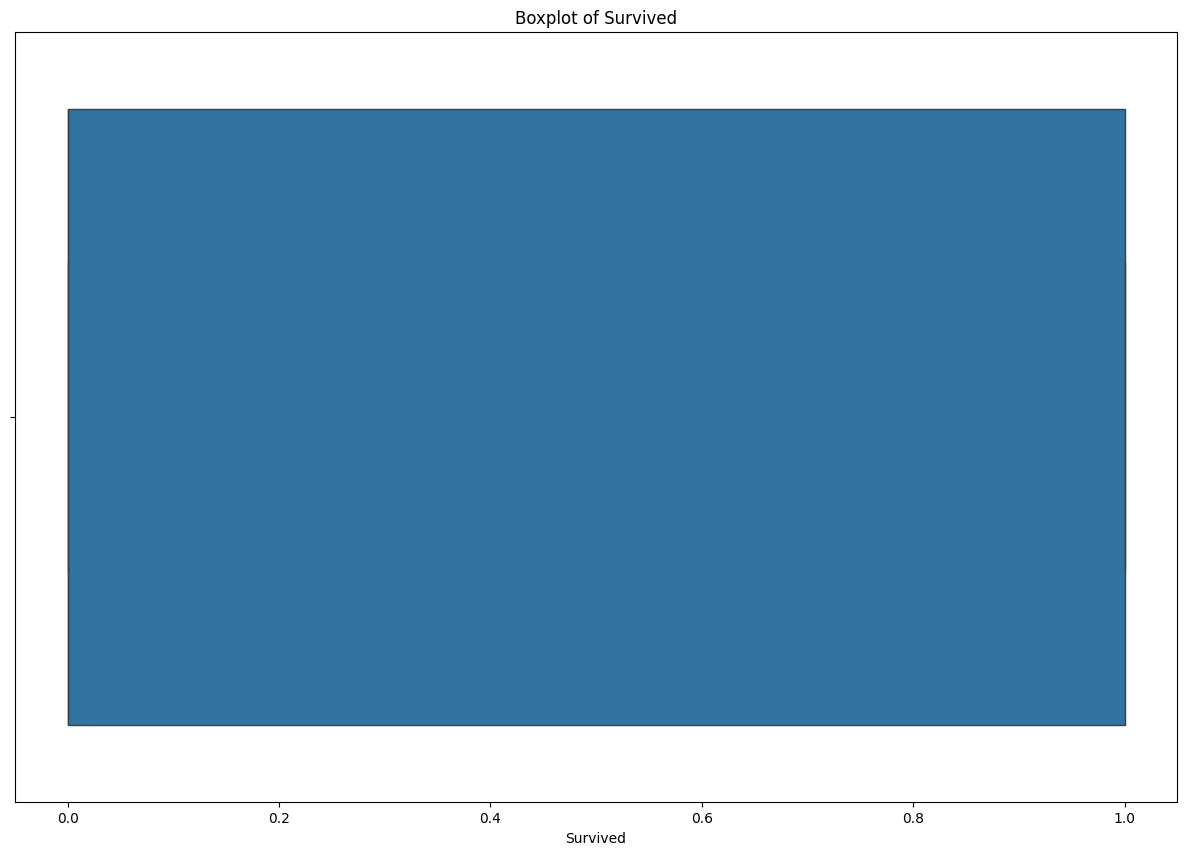

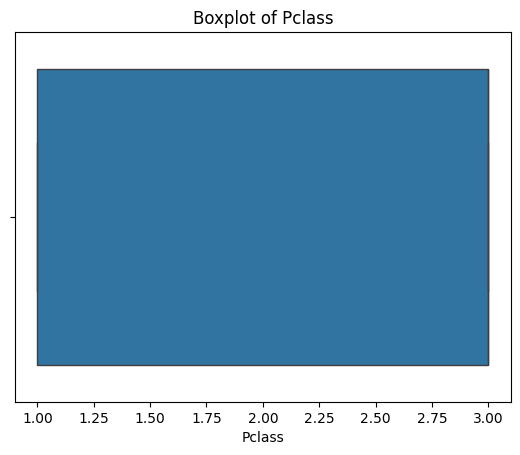

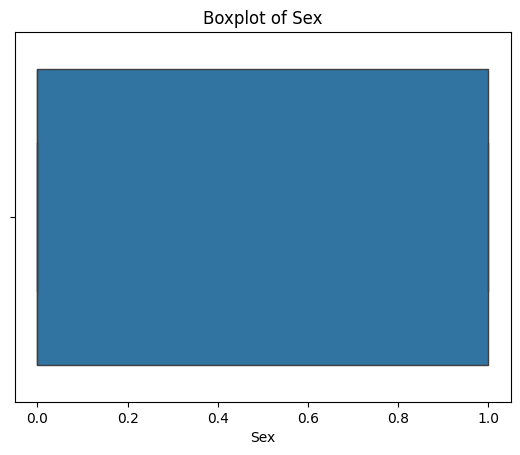

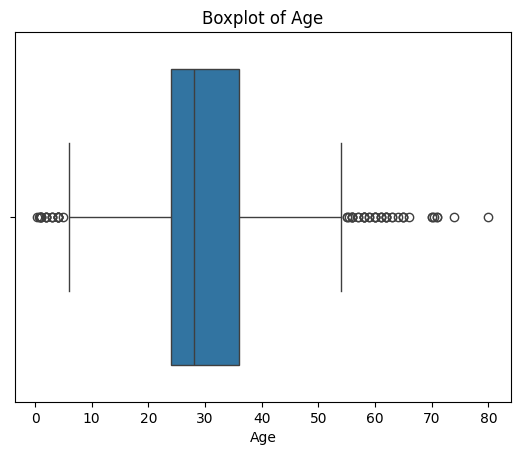

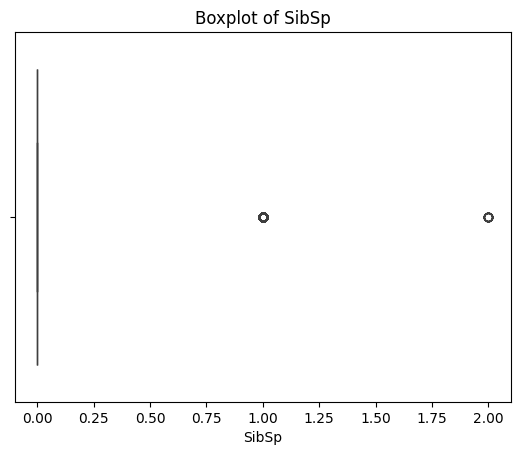

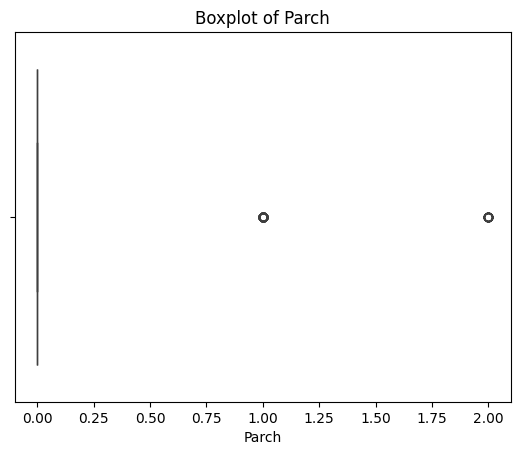

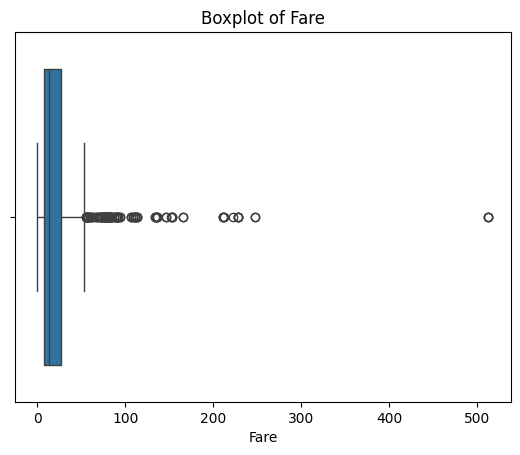

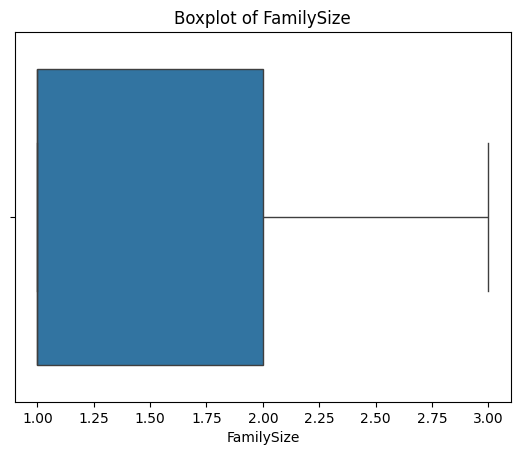

In [26]:
plt.figure(figsize=(15, 10))
for col in numeric_cols:
    sns.boxplot(data=data_copy, x=f'{col}')
    plt.title(f"Boxplot of {col}")
    plt.show()



In [ ]:
print("Informations sur le DataFrame original (`data`):")
display(data.info())
print("Statistiques descriptives du DataFrame original (`data`):")
display(data.describe())

Informations sur le DataFrame original (`data`):
<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    float64
 1   Pclass      891 non-null    float64
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    float64
 5   Parch       891 non-null    float64
 6   Fare        891 non-null    float64
 7   FamilySize  891 non-null    float64
 8   Title_Mr    891 non-null    bool   
 9   Title_Mrs   891 non-null    bool   
 10  Title_Rare  891 non-null    bool   
 11  Embarked_Q  891 non-null    bool   
 12  Embarked_S  891 non-null    bool   
dtypes: bool(5), float64(7), int64(1)
memory usage: 99.3 KB


None

Statistiques descriptives du DataFrame original (`data`):


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,11.000000


#### Jeu de données transformé (`data_transformed`):

In [29]:
print("Informations sur le DataFrame transformé (`data_transformed`):")
display(data_copy.info())
print("Statistiques descriptives du DataFrame transformé (`data_transformed`):")
display(data_copy.describe())

Informations sur le DataFrame transformé (`data_transformed`):
<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 1 to 891
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    800 non-null    float64
 1   Pclass      800 non-null    float64
 2   Sex         800 non-null    int64  
 3   Age         800 non-null    float64
 4   SibSp       800 non-null    float64
 5   Parch       800 non-null    float64
 6   Fare        800 non-null    float64
 7   FamilySize  800 non-null    float64
 8   Title_Mr    800 non-null    bool   
 9   Title_Mrs   800 non-null    bool   
 10  Title_Rare  800 non-null    bool   
 11  Embarked_Q  800 non-null    bool   
 12  Embarked_S  800 non-null    bool   
dtypes: bool(5), float64(7), int64(1)
memory usage: 60.2 KB


None

Statistiques descriptives du DataFrame transformé (`data_transformed`):


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.388750,2.281250,0.327500,30.492188,0.265000,0.191250,29.361140,1.456250
std,0.487771,0.842933,0.469595,12.332163,0.484839,0.476925,47.214302,0.709729
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,0.000000,24.000000,0.000000,0.000000,7.895800,1.000000
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,13.000000,1.000000
75%,1.000000,3.000000,1.000000,36.000000,0.000000,0.000000,26.662500,2.000000
max,1.000000,3.000000,1.000000,80.000000,2.000000,2.000000,512.329200,3.000000


EXERCISE 5

In [33]:
normalized = []
for col in numeric_cols: # Iterate only through numeric columns
  mean_val = data_copy[col].mean()
  median_val = data_copy[col].quantile(0.5) # Corrected from 0.+50 to 0.5
  modes_series = data_copy[col].mode()

  # Check if there is exactly one mode and compare it
  if len(modes_series) == 1:
    mode_val = modes_series.iloc[0] # Access the single mode value
    # Use approximate comparison for floats, but given the user's original code,
    # we will stick to strict equality for now, assuming the user expects exact matches.
    if mean_val == mode_val and mean_val == median_val:
      normalized.append(col)
print(normalized)

[]


In [34]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

scale_standard = StandardScaler()
scale_minmax = MinMaxScaler()

for col in normalized :
  data_copy[col] = scale_standard.fit_transform(data_copy[[col]])

  print(data_copy)

  data_copy[col] = scale_minmax.fit_transform(data_copy[[col]])

  print(data_copy)



EXERCISE 6

In [39]:
import pandas as pd

other = []
for col in data_copy.columns.tolist() :
  if col not in normalized and col in data_copy.select_dtypes(include = "object").columns.tolist() :
    other.append(col)

for col in other :
  if len(set(data_copy[col])) > 2 :
    data_copy = pd.get_dummies(data_copy,columns = [col])
  else :
    val_1 = list(set(data_copy[col]))[0]
    val_2 = list(set(data_copy[col]))[1]

    data_copy[col] = data_copy[col].map({f'{val_1}':0,f'{val_2}':1})

    print(f'{val_1} est encoder par 0')
    print(f'{val_2} est encoder par 1')



data_copy





,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
1,0.0,3.0,0,22.0,1.0,0.0,7.2500,2.0,True,False,False,False,True
2,1.0,1.0,1,38.0,1.0,0.0,71.2833,2.0,False,True,False,False,False
3,1.0,3.0,1,26.0,0.0,0.0,7.9250,1.0,False,False,False,False,True
4,1.0,1.0,1,35.0,1.0,0.0,53.1000,2.0,False,True,False,False,True
5,0.0,3.0,0,35.0,0.0,0.0,8.0500,1.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0.0,3.0,0,25.0,0.0,0.0,7.0500,1.0,True,False,False,False,True
887,0.0,2.0,0,27.0,0.0,0.0,13.0000,1.0,False,False,True,False,True
888,1.0,1.0,1,19.0,0.0,0.0,30.0000,1.0,False,False,False,False,True


EXERCISE 7

In [49]:
kid = list(range(0,15))
Teenager = list(range(15,25))
Adult = list(range(25,65))
age_group =[]
for i in data_copy['Age'] :
  if int(i) in kid :
    age_group.append('kid')
  elif int(i) in Teenager :
    age_group.append('Teenager')
  elif int(i) in Adult :
    age_group.append('Adult')
  else :
    age_group.append('Senior')

data_copy['age_group'] = age_group
data_copy = pd.get_dummies(data_copy,columns = ['age_group'])



In [51]:
data_copy = data_copy.T.drop_duplicates().T
data_copy

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S,age_group_Adult,age_group_Senior,age_group_Teenager,age_group_kid
PassengerId,,,,,,,,,,,,,,,,,
1,0.0,3.0,0,22.0,1.0,0.0,7.25,2.0,True,False,False,False,True,False,False,True,False
2,1.0,1.0,1,38.0,1.0,0.0,71.2833,2.0,False,True,False,False,False,True,False,False,False
3,1.0,3.0,1,26.0,0.0,0.0,7.925,1.0,False,False,False,False,True,True,False,False,False
4,1.0,1.0,1,35.0,1.0,0.0,53.1,2.0,False,True,False,False,True,True,False,False,False
5,0.0,3.0,0,35.0,0.0,0.0,8.05,1.0,True,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0.0,3.0,0,25.0,0.0,0.0,7.05,1.0,True,False,False,False,True,True,False,False,False
887,0.0,2.0,0,27.0,0.0,0.0,13.0,1.0,False,False,True,False,True,True,False,False,False
888,1.0,1.0,1,19.0,0.0,0.0,30.0,1.0,False,False,False,False,True,False,False,True,False
